In [75]:
import requests
import pandas as pd
import numpy as np
from binance.client import Client
import datetime

from itertools import combinations
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm


## Load Data and filter the top 20 by market cap

In [76]:
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,   # pull more so filtering still leaves ~20
    "page": 1,
    "sparkline": False
    
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data)[
    ["market_cap_rank", "symbol", "name", "market_cap", "current_price"]
]

# -----------------------------
# Filters
# -----------------------------

stablecoins = {
    "usdt", "usdc", "busd", "dai", "tusd",
    "usdp", "fdusd", "gusd", "lusd",
    "ust", "ustc", "usdd", "eurc",'usds','usde','bsc-usd','usd1','pyusd'
    
}

# normalize text
df["symbol"] = df["symbol"].str.lower()
df["name"] = df["name"].str.lower()

# remove stablecoins
df = df[~df["symbol"].isin(stablecoins)]

# remove wrapped coins
df = df[
    ~df["name"].str.contains("wrapped") &
    ~df["symbol"].str.startswith("w")
]

# take top 20 after filtering
df = df.sort_values("market_cap", ascending=False).head(20)

print(df)


    market_cap_rank      symbol          name     market_cap  current_price
0                 1         btc       bitcoin  1336114395872   66736.000000
1                 2         eth      ethereum   241372724221    1997.800000
3                 4         bnb           bnb    83482257312     612.020000
4                 5         xrp           xrp    81824872919       1.330000
6                 7         sol        solana    47157299231      82.350000
7                 8         trx          tron    30271911657       0.319522
8                 9  figr_heloc  figure heloc    16564598468       1.019000
9                10        doge      dogecoin    13953070820       0.090803
12               13         bch  bitcoin cash     9643845549     481.550000
13               14        hype   hyperliquid     9329773085      39.140000
14               15         ada       cardano     8944335242       0.242976
15               16         leo     leo token     8891608299       9.650000
16          

## Get symbol from Binance, using binance data and later using binance api for trading test.


In [77]:
binance_symbols = requests.get(
    "https://api.binance.com/api/v3/exchangeInfo"
).json()

binance_assets = {
    s["baseAsset"].lower()
    for s in binance_symbols["symbols"]
    if s["quoteAsset"] == "USDT"
}

df = df[df["symbol"].isin(binance_assets)]

In [78]:
client = Client()


def get_close_prices_15m(
    client,
    symbols,
    start_date,
    end_date
):

    close_dfs = []

    for sym in symbols:
        pair = sym.upper() + "USDT"
        print(f"Downloading {pair}")

        klines = client.get_historical_klines(
            pair,
            Client.KLINE_INTERVAL_15MINUTE,
            start_date.strftime("%d %b %Y %H:%M:%S"),
            end_date.strftime("%d %b %Y %H:%M:%S")
        )
        

        df = pd.DataFrame(klines, columns=[
            "timestamp", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base", "taker_buy_quote", "ignore"
        ])

        df = df[["timestamp", "close"]]
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        df["close"] = df["close"].astype(float)

        df = df.rename(columns={"close": sym.upper()})
        

        close_dfs.append(df)

    # ---- merge all coins on timestamp ----
    df_close = close_dfs[0]

    for d in close_dfs[1:]:
        df_close = df_close.merge(
            d,
            on="timestamp",
            how="outer"
        )

    df_close = (
        df_close
        .sort_values("timestamp")
        .set_index("timestamp")
    )

    return df_close


In [79]:
#start_date = datetime(2025, 1, 1)
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(days=90)


df_close_15m = get_close_prices_15m(
    client,
    df['symbol'].tolist(),
    start_date,
    end_date
)

### visualise price change over time

In [80]:
import numpy as np

base = df_close_15m.iloc[0]
bad_cols = base[(base.isna()) | (base == 0)].index
print("Bad columns:", bad_cols)
df_close_15m = df_close_15m.drop(columns=bad_cols)

Bad columns: Index(['XMR'], dtype='object')


Text(0, 0.5, 'Log Price')

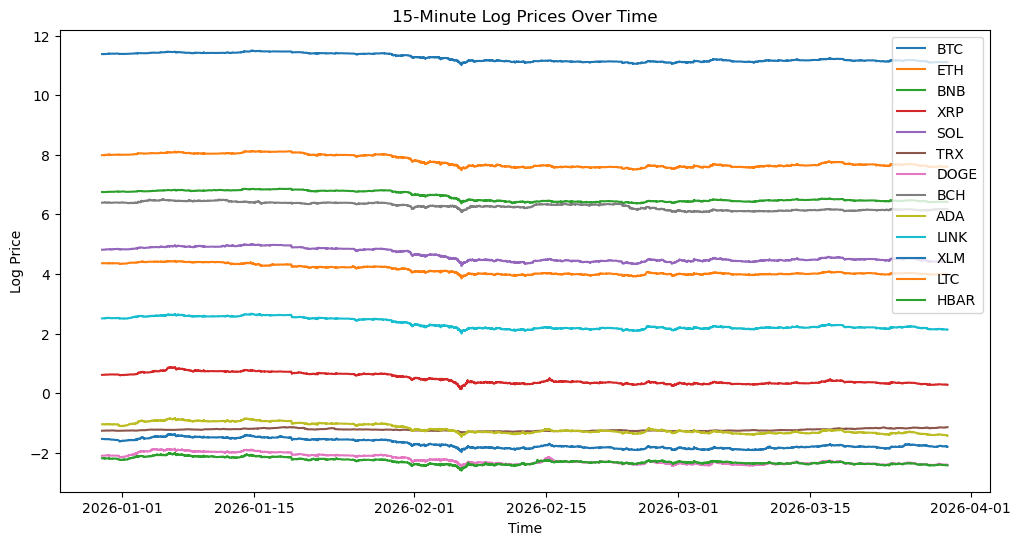

In [81]:
import matplotlib.pyplot as plt

log_df = np.log(df_close_15m)  # Log prices for cointegration analysis

plt.figure(figsize=(12, 6))
for col in log_df.columns:
    plt.plot(log_df.index, log_df[col], label=col)
plt.legend()
plt.title("15-Minute Log Prices Over Time")
plt.xlabel("Time")
plt.ylabel("Log Price")

In [82]:
df_close=df_close_15m.copy()

In [83]:
df_close_15m.dropna(inplace=True, axis=0)

In [84]:
df_close_15m

,BTC,ETH,BNB,XRP,SOL,TRX,DOGE,BCH,ADA,LINK,XLM,LTC,HBAR
timestamp,,,,,,,,,,,,,
2025-12-29 21:15:00,87292.64,2933.42,853.47,1.8495,123.33,0.2840,0.12279,596.0,0.3526,12.30,0.2159,78.17,0.11292
2025-12-29 21:30:00,87358.53,2939.16,854.43,1.8539,123.57,0.2842,0.12298,596.9,0.3529,12.33,0.2162,78.30,0.11318
2025-12-29 21:45:00,87337.85,2937.33,854.74,1.8539,123.45,0.2844,0.12291,596.5,0.3528,12.33,0.2162,78.28,0.11378
2025-12-29 22:00:00,87128.55,2933.09,853.11,1.8481,123.24,0.2838,0.12254,596.0,0.3531,12.33,0.2159,78.27,0.11326
2025-12-29 22:15:00,87225.02,2937.50,853.52,1.8509,123.29,0.2839,0.12283,595.9,0.3542,12.34,0.2157,78.19,0.11334
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-29 12:00:00,66773.06,2002.39,612.70,1.3356,82.42,0.3194,0.09080,481.9,0.2428,8.50,0.1668,53.91,0.08939
2026-03-29 12:15:00,66781.62,2002.69,612.69,1.3361,82.41,0.3196,0.09079,482.9,0.2429,8.50,0.1671,53.85,0.08944
2026-03-29 12:30:00,66738.00,1999.08,611.94,1.3337,82.26,0.3197,0.09066,482.7,0.2423,8.48,0.1668,53.80,0.08923


## Run Cointegration Test
### select BTC related pairs

用 kalman 找cointegration with BTC
traditional: OLS find beta, then check stationarity of spread
Dynamic: use kalman filter to find rolling beta, then check stationarity of spread
Stationary of spread: adf test

假设资产 Y 和资产 X 存在线性关系：

\begin{align}
\theta_t &= \theta_{t-1} + w_t \\
y_t &= \alpha_t + \beta_t x_t + v_t
\end{align}




\begin{align}
S_t &= H_t P_{t\mid t-1} H_t^T + R \\
K_t &= P_{t\mid t-1} H_t^T S_t^{-1} \\
\hat{\theta}_{t\mid t} &= \hat{\theta}_{t\mid t-1} + K_t e_t \\
P_{t\mid t} &= (I - K_t H_t)\, P_{t\mid t-1}
\end{align}

Ke用来模拟参数不确定，R用来模拟观测噪声


\section*{每日第一步：预测 (Prediction Step)}

时间来到新的一天，开盘前，算法基于昨天的记忆进行“盲猜”。

\begin{align}
\hat{\theta}_{t\mid t-1} &\quad \text{(state\_mean\_pred)：先验状态估计} \\
&= \hat{\theta}_{t-1\mid t-1} \\
\\
P_{t\mid t-1} &\quad \text{(state\_cov\_pred)：先验状态协方差} \\
&= P_{t-1\mid t-1} + Q
\end{align}



\section*{每日第二步：更新 / 纠偏 (Update Step)}

收盘后，观察到真实价格 $y_t$，算法开始修正预测。

\begin{align}
y_{\text{pred}} &= H_t \hat{\theta}_{t\mid t-1} \\
\\
e_t &= y_t - y_{\text{pred}} \\
\\
S_t &= H_t P_{t\mid t-1} H_t^T + R \\
\\
K_t &= P_{t\mid t-1} H_t^T S_t^{-1} \\
\\
K_t e_t &\quad \text{(实际纠偏量)}
\end{align}



好的，我们抛开刚才的比喻，纯从**数理统计与最优估计理论**的角度，来极其严谨地推导这两个公式。

我们当前面临的是一个**线性高斯状态空间模型 (Linear Gaussian State-Space Model)**。

### 0. 模型的数学定义
我们试图估计的隐藏状态（也就是 Alpha 和 Beta）构成状态向量：
$\theta_t = \begin{bmatrix} \alpha_t \\ \beta_t \end{bmatrix}$ (对应代码中的 `state_mean`)

*   **状态方程 (State Equation)：** 假设状态是随机游走的
    $\theta_t = \theta_{t-1} + w_t \quad, \quad w_t \sim \mathcal{N}(0, Q)$
*   **观测方程 (Observation Equation)：** 我们观测到的资产 Y 的价格 $y_t$ 为：
    $y_t = H_t \theta_t + v_t \quad, \quad v_t \sim \mathcal{N}(0, R)$
    其中 $H_t = [1, x_t]$ 为观测矩阵。$v_t$ 是测量噪声，$w_t$ 是过程噪声，二者相互独立。

在预测步（Prediction Step）之后，我们得到了当前的**先验状态估计 $\hat{\theta}_{t|t-1}$** (`state_mean_pred`) 以及它的**先验协方差矩阵 $P_{t|t-1}$** (`state_cov_pred`)。

现在我们迎来了时刻 $t$ 的真实观测数据 $y_t$。

---

### 1. `S` 是什么？ —— 新息协方差 (Innovation Covariance)

当我们只有先验估计时，对当前观测值 $y_t$ 理论上的预期是：
$\hat{y}_{t|t-1} = H_t \hat{\theta}_{t|t-1}$ （对应代码 `y_pred`）

那么，真实观测 $y_t$ 与预期的差值，在数学上被称为**新息 (Innovation)**，记作 $\tilde{y}_t$：
$\tilde{y}_t = y_t - \hat{y}_{t|t-1}$ （对应代码 `error`）

**`S` 的严格定义，就是这个新息 $\tilde{y}_t$ 的理论方差（由于输出是一维的，所以它是标量）：**
$S_t = \text{Var}(\tilde{y}_t)$

我们来推导它：
$S_t = \text{Var}(y_t - H_t \hat{\theta}_{t|t-1})$
代入观测方程 $y_t = H_t \theta_t + v_t$：
$S_t = \text{Var}(H_t \theta_t + v_t - H_t \hat{\theta}_{t|t-1})$
提取同类项：
$S_t = \text{Var}(H_t (\theta_t - \hat{\theta}_{t|t-1}) + v_t)$

根据定义，$(\theta_t - \hat{\theta}_{t|t-1})$ 就是我们先验估计的误差，它的方差就是先验协方差矩阵 $P_{t|t-1}$ (`state_cov_pred`)。而且状态估计误差与当前的测量噪声 $v_t$ 相互独立。所以根据方差的线性性质：
$S_t = H_t \cdot \text{Var}(\theta_t - \hat{\theta}_{t|t-1}) \cdot H_t^T + \text{Var}(v_t)$
$$S_t = H_t P_{t|t-1} H_t^T + R$$

**数学结论：** `S` 描述了在观测空间中，系统在这个时刻总的理论预测方差。左侧 $H P H^T$ 是**由于参数 $\theta$ 估计不准映射到观测空间带来的方差**，右侧 $R$ 是**系统固有的测量噪声方差**。

---

### 2. `K` 是什么？ —— 最优卡尔曼增益 (Optimal Kalman Gain)

现在我们要结合新息，把先验估计修正为**后验估计** $\hat{\theta}_{t|t}$。修正采取线性组合的形式：
$\hat{\theta}_{t|t} = \hat{\theta}_{t|t-1} + K_t \tilde{y}_t$ （对应代码 `state_mean = state_mean_pred + K * error`）

**核心问题来了：这里的系数矩阵 $K_t$ 怎么取？**
卡尔曼滤波的数学优化目标是：**使得修改后的后验估计误差的协方差（即均方误差 MSE）最小化。** 
也就是最小化后验协方差矩阵的对角线元素之和： $\min \text{Trace}(P_{t|t})$

我们先写出后验估计误差 $e_{t|t} = \theta_t - \hat{\theta}_{t|t}$，并推导其协方差 $P_{t|t}$ (跳过冗长的展开步骤，由独立性可得经典的 Joseph Form)：
$P_{t|t} = (I - K_t H_t) P_{t|t-1} (I - K_t H_t)^T + K_t R K_t^T$

为了找到让迹（Trace）最小的 $K_t$，我们对上式的迹关于矩阵 $K_t$ 求偏导，并令其等于 0：
$\frac{\partial \, \text{Trace}(P_{t|t})}{\partial K_t} = -2(I - K_t H_t)P_{t|t-1}H_t^T + 2K_t R = 0$

解这个关于 $K_t$ 的矩阵方程：
$P_{t|t-1}H_t^T - K_t H_t P_{t|t-1}H_t^T - K_t R = 0$
$P_{t|t-1}H_t^T = K_t (H_t P_{t|t-1}H_t^T + R)$

你注意到了吗？括号里的恰好就是我们上面推导过的 $S_t$！
$P_{t|t-1}H_t^T = K_t S_t$
移项求解最优增益 $K_t$（由于 $S$ 在一维观测下是标量，所以矩阵求逆变成了普通除法）：
$$K_t = P_{t|t-1} H_t^T S_t^{-1} \ \ \Rightarrow \ \ K = \frac{P_{t|t-1} H^T}{S}$$

**(这也正好是你代码里的 `K = state_cov_pred.dot(H.T) / S`)**

**数学结论：** 
卡尔曼增益 $K_t$ 是在**最小均方误差（MMSE）准则下，通过对后验协方差求极值计算出的最优权重矩阵**。
它在数学意义上等于**【状态与观测的交叉协方差】 ($P_{t|t-1} H^T$) 处以【观测总新息方差】($S$)。** 
它利用协方差的数学性质，精确计算出了在多大维度、多大程度上把观测带来的修正“平摊”给状态向量中的 Alpha 和 Beta。

In [85]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from itertools import combinations

def test_cointegration_kalman(series_x, series_y, delta=1e-5):
    """
    Stationarity test using a Kalman Filter for dynamic hedge ratios
    """
    # Kalman Filter to calculate rolling Alpha and Beta
    state_mean = np.zeros(2) # used to put initial value of alpha and beta
    state_cov = np.ones((2, 2)) # P: Initial uncertainty
    
    Q = (delta / (1 - delta)) * np.eye(2) # Parameter drift
    R = 1.0 # Observation noise
    # Q and R: if Q is large, the filter will adapt quickly to new data, but it will also be more sensitive to noise. 
    # if R is large, the filter will be more conservative and less sensitive to noise.
    # delta: the smaller the delta, the slower the filter will adapt to new data, but it will also be more sensitive to noise.
    
    rolling_alpha = []
    rolling_beta = []
    
    # Iterate through the time series
    for i in range(len(series_x)):
        x_t = series_x.iloc[i]
        y_t = series_y.iloc[i]
        
        H = np.array([[1.0, x_t]])
        
        # Prediction Step
        state_mean_pred = state_mean
        state_cov_pred = state_cov + Q # P: var(theta hat - theta) Variance of theta estimation error: add Q daily: uncertainty
        
        # Update Step
        y_pred = H.dot(state_mean_pred)
        error = y_t - y_pred
        
        S = H.dot(state_cov_pred).dot(H.T) + R # Total confusion var(error) = theta uncertainty + R (observation noise)
        K = state_cov_pred.dot(H.T) / S  # Uncertainty / Total confusion -> Kalman Gain. K ~ P/S
        
        state_mean = state_mean_pred + (K.flatten() * error)
        state_cov = (np.eye(2) - K.dot(H)).dot(state_cov_pred)
        
        rolling_alpha.append(state_mean[0])
        rolling_beta.append(state_mean[1])
        
    rolling_alpha = pd.Series(rolling_alpha, index=series_x.index)
    rolling_beta = pd.Series(rolling_beta, index=series_x.index)

    # 2️⃣ Calculate Dynamic Spread
    spread = series_y - (rolling_beta * series_x + rolling_alpha)

    # 3️⃣ Stationarity test (ADF) directly on the dynamic spread
    # We drop NA values that might occur during the initial filter convergence
    adf_result = adfuller(spread.dropna())
    
    t_stat = adf_result[0]
    pvalue = adf_result[1]
    crit_values = adf_result[4]

    return {
        "latest_beta": rolling_beta.iloc[-1], # Return the most recent beta for the summary table
        "pvalue": pvalue,
        "t_stat": t_stat,
        "crit_1%": crit_values['1%'],
        "crit_5%": crit_values['5%'],
        "crit_10%": crit_values['10%'],
        "spread": spread,
        "rolling_beta_series": rolling_beta # Stored in case you need to plot it later
    }

# --- Execution Loop ---
results = []
pairs = list(combinations(log_df.columns, 2))

for x, y in pairs:
    res = test_cointegration_kalman(log_df[x], log_df[y])

    results.append({
        "pair": f"{x}-{y}",
        "x": x,
        "y": y,
        "latest_beta": res["latest_beta"],
        "pvalue": res["pvalue"],
        "t_stat": res["t_stat"],
        "crit_5%": res["crit_5%"]
    })

# Format and filter the results
df_coint = pd.DataFrame(results)
coint_pairs = df_coint[df_coint["pvalue"] < 0.05]
coint_pairs = coint_pairs.sort_values("pvalue")

# Filter for pairs specifically involving BTC
btc_pairs = coint_pairs[
    (coint_pairs["x"] == "BTC") |
    (coint_pairs["y"] == "BTC")
]

display(btc_pairs)

,pair,x,y,latest_beta,pvalue,t_stat,crit_5%
8,BTC-LINK,BTC,LINK,0.175121,3.320458e-23,-12.466261,-2.861876
0,BTC-ETH,BTC,ETH,0.626720,3.596947e-22,-11.986824,-2.861876
3,BTC-SOL,BTC,SOL,0.362824,5.323504e-20,-11.042465,-2.861876
4,BTC-TRX,BTC,TRX,-0.094065,6.692601e-20,-11.000736,-2.861876
9,BTC-XLM,BTC,XLM,-0.148789,2.423469e-19,-10.768087,-2.861877
7,BTC-ADA,BTC,ADA,-0.118299,2.949378e-19,-10.732855,-2.861876
11,BTC-HBAR,BTC,HBAR,-0.200669,6.448582e-19,-10.593190,-2.861877
5,BTC-DOGE,BTC,DOGE,-0.199714,6.471399e-19,-10.592562,-2.861877
10,BTC-LTC,BTC,LTC,0.327802,9.025649e-19,-10.533475,-2.861877
6,BTC-BCH,BTC,BCH,0.509921,4.086089e-18,-10.267354,-2.861877


Analyzing the most cointegrated pair: BTC & LINK


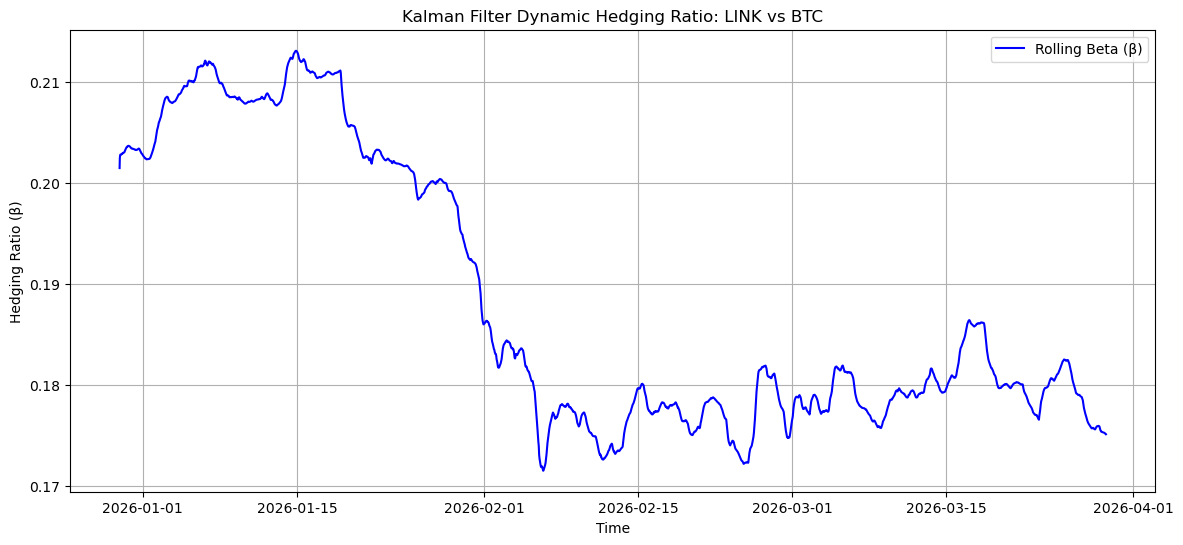

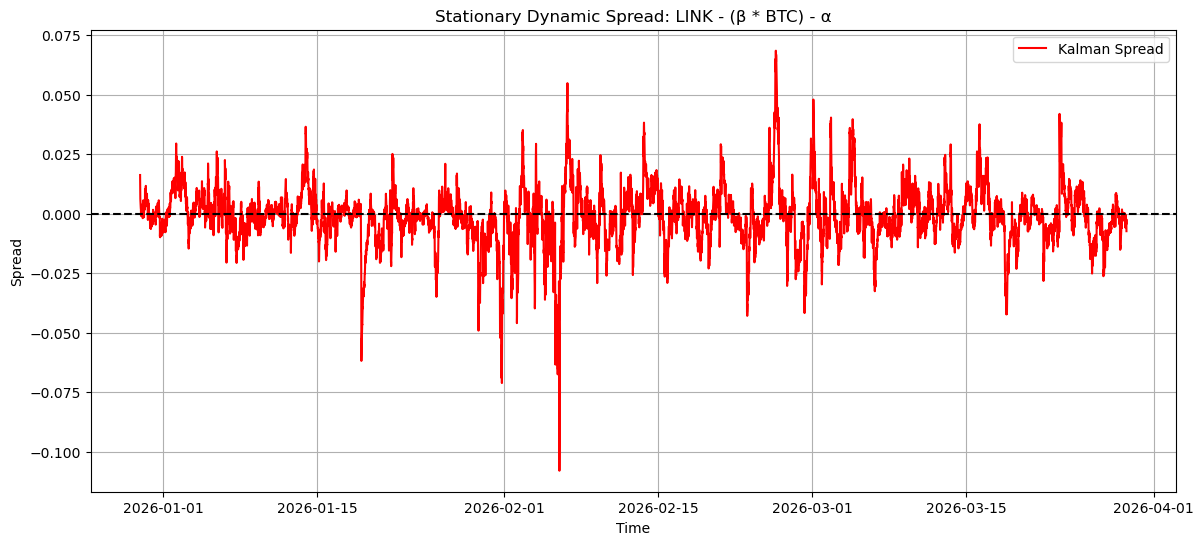

In [86]:
import matplotlib.pyplot as plt

# 1. Select the most cointegrated BTC pair (the one with the lowest p-value)
best_x = btc_pairs.iloc[0]['x']
best_y = btc_pairs.iloc[0]['y']
print(f"Analyzing the most cointegrated pair: {best_x} & {best_y}")

# 2. Re-run the Kalman Filter specifically for this pair to get the full time series
kalman_results = test_cointegration_kalman(log_df[best_x], log_df[best_y])

rolling_beta = kalman_results["rolling_beta_series"]
dynamic_spread = kalman_results["spread"]

# 3. Plot the Dynamic Hedging Ratio (Beta)
plt.figure(figsize=(14, 6))
plt.plot(rolling_beta.index, rolling_beta, label=f'Rolling Beta (\u03b2)', color='blue')
plt.title(f'Kalman Filter Dynamic Hedging Ratio: {best_y} vs {best_x}')
plt.xlabel('Time')
plt.ylabel('Hedging Ratio (\u03b2)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Plot the resulting Dynamic Spread for visualization
plt.figure(figsize=(14, 6))
plt.plot(dynamic_spread.index, dynamic_spread, label='Kalman Spread', color='red')
plt.axhline(0, color='black', linestyle='--', lw=1.5)
plt.title(f'Stationary Dynamic Spread: {best_y} - (\u03b2 * {best_x}) - \u03b1')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.show()

## Modelling

In [87]:


def build_spread(prices: pd.DataFrame, x: str, y: str, beta: float, use_log=True):
    px = prices[x].astype(float)
    py = prices[y].astype(float)
    if use_log:
        px = np.log(px)
        py = np.log(py)
    spread = py - beta * px
    return spread.dropna()

算spread的mean, lambda(half_life)->多久能回归

In [88]:
import statsmodels.api as sm
from arch import arch_model
import numpy as np
import pandas as pd

def fit_ou_from_spread(spread: pd.Series, delta=1.0):
    s = spread.values
    s_t = s[:-1]
    s_t1 = s[1:]

    X = sm.add_constant(s_t)
    res = sm.OLS(s_t1, X).fit()

    b = float(res.params[0])
    a = float(res.params[1])

    if not (0 < a < 1):
        return None  

    eps = res.resid
    lam = -np.log(a) / delta
    mu = b / (1 - a)

    # --- Fixed and robust GARCH calculation ---
    try:
        am = arch_model(pd.Series(s).diff().dropna(), vol='Garch', p=1, q=1, rescale=True)
        garch_res = am.fit(disp='off')
        
        omega = garch_res.params['omega']
        alpha = garch_res.params['alpha[1]']
        beta_p = garch_res.params['beta[1]']
        persist = alpha + beta_p
        

        if persist >= 1.0 or persist <= 0.0:
            raise ValueError("GARCH non-stationary")
            
        sigma = np.sqrt(omega / (1 - persist)) / garch_res.scale
    except:
    
        sigma = float(np.std(eps, ddof=1)) 

    half_life = np.log(2) / lam

    return {
        "a": a, "b": b,
        "lambda": lam,
        "mu": mu,
        "sigma": sigma,
        "half_life": half_life,
        "r2": float(res.rsquared)
    }


In [89]:
def ou_zscore(spread: pd.Series, mu: float, sigma: float):
    return (spread - mu) / sigma

def zscore_signals(z: pd.Series, entry_z=2.5, exit_z=0.5, min_hold=16):
    """

    """
    sig = pd.Series(0, index=z.index, dtype=int)
    current_pos = 0
    bars_held = 0
    
    for i in range(len(z)):
        val = z.iloc[i]
        
        if current_pos == 0:
            if val > entry_z:
                current_pos = -1
                bars_held = 0
            elif val < -entry_z:
                current_pos = 1
                bars_held = 0
        else:
            bars_held += 1
            if bars_held >= min_hold:
                if current_pos == 1 and val >= exit_z:
                    current_pos = 0
                elif current_pos == -1 and val <= -exit_z:
                    current_pos = 0
                    
        sig.iloc[i] = current_pos
        
    return sig



Regime Detection + Rolling Cointegration
**Goal:** Prevent trading during structural breaks by filtering signals with a regime indicator.

- Rolling ADF test → track rolling p-value and t-stat
- Rolling half-life → detect when mean-reversion breaks down
- Regime signal: 1 = allow trading (green light), 0 = halt trading (red light)

In [90]:
def generate_regime_signals(kalman_spread, window=200, step=5,
                             p_val_threshold=0.1, max_halflife=200):
    """
    Jiayi's Regime Detection Module.

    Rolls a window over the Kalman spread and at each step computes:
      1. ADF test  -> rolling p-value and t-stat
      2. OU half-life via OLS regression on delta_spread ~ spread_lag

    Regime rule:
      GREEN (1): p-value < threshold  AND  0 < half-life < max_halflife
      RED   (0): otherwise (structural break or spread not mean-reverting)

    Parameters
    ----------
    kalman_spread     : pd.Series  – dynamic spread from Weisiang's Kalman filter
    window            : int        – look-back window in bars (200 bars ≈ 50 hrs on 15-min data)
    step              : int        – re-compute every `step` bars (speeds up the loop)
    p_val_threshold   : float      – ADF p-value cut-off (default 0.10)
    max_halflife      : int        – max acceptable half-life in bars (200 ≈ 50 hrs)

    Returns
    -------
    pd.DataFrame with columns: p_value, t_stat, half_life, regime_signal
    """
    results = pd.DataFrame(index=kalman_spread.index)
    results['p_value']       = np.nan
    results['t_stat']        = np.nan
    results['half_life']     = np.nan
    results['regime_signal'] = np.nan

    for i in range(window, len(kalman_spread), step):
        current_spread = kalman_spread.iloc[i - window : i]
        idx = current_spread.index[-1]

        # ── 1. Rolling ADF test ───────────────────────────────────────────
        try:
            from statsmodels.tsa.stattools import adfuller
            adf_res        = adfuller(current_spread, maxlag=1, autolag=None)
            p_val, t_stat  = adf_res[1], adf_res[0]
        except Exception as e:
            print(f"ADF error at {idx}: {e}")
            p_val, t_stat  = 1.0, 0.0

        results.loc[idx, 'p_value'] = p_val
        results.loc[idx, 't_stat']  = t_stat

        # ── 2. Rolling half-life (OU via OLS) ────────────────────────────
        # Regression: Δspread_t = λ * spread_{t-1} + ε
        # half-life  = -ln(2) / λ   (λ must be negative for mean-reversion)
        try:
            y        = current_spread.values
            y_lag    = y[:-1]
            delta_y  = y[1:] - y_lag
            lam      = sm.OLS(delta_y, sm.add_constant(y_lag)).fit().params[1]
            half_life = -np.log(2) / lam if lam < 0 else np.inf
        except Exception as e:
            print(f"Half-life error at {idx}: {e}")
            half_life = np.inf

        results.loc[idx, 'half_life'] = half_life

        # ── 3. Regime rule ───────────────────────────────────────────────
        if (p_val < p_val_threshold) and (0 < half_life < max_halflife):
            results.loc[idx, 'regime_signal'] = 1   # green – allow trading
        else:
            results.loc[idx, 'regime_signal'] = 0   # red   – halt trading

    # Forward-fill between computation steps; default to 0 (red) at the start
    results['regime_signal'] = (
        results['regime_signal']
        .ffill()
        .fillna(0)
        .astype(int)
    )
    return results

In [91]:
def walk_forward_signals(prices, x, y, train_window, trade_window):
    """
    Walk‑forward signal generation using the Kalman‑derived hedge ratio
    from the training window.
    """
    signals = []
    z_scores = []

    for start in range(train_window, len(prices) - trade_window, trade_window):
        train = prices.iloc[start - train_window:start]
        test  = prices.iloc[start:start + trade_window]

        # ---- 1. Obtain Kalman beta from training window ----
        # test_cointegration_kalman returns a dict with 'latest_beta'
        kalman_res = test_cointegration_kalman(train[x], train[y])
        beta = kalman_res["latest_beta"]   # float, final hedge ratio

        # ---- 2. Build spread using this beta ----
        spread_train = train[y] - beta * train[x]

        # ---- 3. Fit OU process to the spread ----
        ou = fit_ou_from_spread(spread_train)
        if ou is None:
            # Skip this window if OU parameters are invalid
            continue

        # ---- 4. Compute z‑score on test window ----
        spread_test = test[y] - beta * test[x]
        z = ou_zscore(spread_test, ou["mu"], ou["sigma"])

        # ---- 5. Generate trading signals ----
        sig = zscore_signals(z, entry_z=2.0, exit_z=0.0) 


        signals.append(sig)
        z_scores.append(z)

    if not signals:
        # Return empty series if no windows succeeded
        return pd.Series(dtype=float), pd.Series(dtype=int)

    signals = pd.concat(signals)
    z_scores = pd.concat(z_scores)
    return z_scores, signals

In [92]:
def walk_forward_dynamic_btc_pairs(prices, train_window=24*4*25, trade_window=24*4, pvalue_threshold=0.05, max_halflife=24*4*2):
    log_prices = np.log(prices)
    cols = log_prices.columns.tolist()
    pair_data = {}
    
    # 1. Pre-run strict Kalman filter on global data without lookahead bias
    print("Pre-calculating global Kalman filters...")
    kf_results = {}
    for other in cols:
        if other == "BTC":
            continue
        x, y = "BTC", other
        pair_str = f"{x}-{y}"
        kf_results[pair_str] = test_cointegration_kalman(log_prices[x], log_prices[y])

    # 2. Walk-forward loop
    for start in range(train_window, len(log_prices) - trade_window, trade_window):
        for other in cols:
            if other == "BTC":
                continue

            x, y = "BTC", other
            pair_str = f"{x}-{y}"

            kf_res = kf_results[pair_str]
            spread_full = kf_res["spread"]
            beta_full = kf_res["rolling_beta_series"]

            # Strictly split train and test to avoid lookahead bias
            spread_train = spread_full.iloc[start - train_window : start]
            spread_test  = spread_full.iloc[start : start + trade_window]

            # Regime filter 1: ADF test (run only on train)
            from statsmodels.tsa.stattools import adfuller
            adf_result = adfuller(spread_train.dropna())
            pvalue = adf_result[1]
            if pvalue >= pvalue_threshold:
                continue  

            # Fit OU model (run only on train)
            ou = fit_ou_from_spread(spread_train)
            if ou is None:
                continue

            # Regime filter 2: Half-life filtering (run only on train)
            if not (0 < ou["half_life"] < max_halflife):
                continue
            
            # If both regimes pass, issue signal on test using current parameters to calculate z-score
            z = ou_zscore(spread_test, ou["mu"], ou["sigma"])
            lookback = max(10, len(z) // 4)
            sig = zscore_signals(z, entry_z=2.5, exit_z=0, min_hold = 16)

            if pair_str not in pair_data:
                pair_data[pair_str] = {"signals": [], "z_scores": [], "beta": []}

            pair_data[pair_str]["signals"].append(sig)
            pair_data[pair_str]["z_scores"].append(z)
            # Store the true dynamic Beta list at this moment
            pair_data[pair_str]["beta"].append(beta_full.iloc[start : start + trade_window])

    results = []
    for pair_str, data in pair_data.items():
        if not data["signals"]:
            continue
        results.append({
            "pair":     pair_str,
            "beta":     pd.concat(data["beta"]),
            "z_scores": pd.concat(data["z_scores"]),
            "signal":   pd.concat(data["signals"])
        })

    return results


In [93]:
ou_results = walk_forward_dynamic_btc_pairs(df_close_15m)
print(f"Dynamic pair selection found {len(ou_results)} BTC pairs with cointegration signal")
for r in ou_results:
    print(f"  {r['pair']}: {len(r['signal'])} signal bars")

Pre-calculating global Kalman filters...
Dynamic pair selection found 12 BTC pairs with cointegration signal
  BTC-ETH: 6144 signal bars
  BTC-BNB: 6144 signal bars
  BTC-XRP: 6048 signal bars
  BTC-SOL: 6144 signal bars
  BTC-TRX: 6144 signal bars
  BTC-DOGE: 6144 signal bars
  BTC-BCH: 6144 signal bars
  BTC-ADA: 6144 signal bars
  BTC-LINK: 6144 signal bars
  BTC-XLM: 6144 signal bars
  BTC-LTC: 6144 signal bars
  BTC-HBAR: 6144 signal bars


In [94]:
ou_results

[{'pair': 'BTC-ETH',
  'beta': timestamp
  2026-01-23 21:15:00    0.644118
  2026-01-23 21:30:00    0.644115
  2026-01-23 21:45:00    0.644114
  2026-01-23 22:00:00    0.644115
  2026-01-23 22:15:00    0.644119
                           ...   
  2026-03-28 20:00:00    0.627163
  2026-03-28 20:15:00    0.627172
  2026-03-28 20:30:00    0.627179
  2026-03-28 20:45:00    0.627189
  2026-03-28 21:00:00    0.627198
  Length: 6144, dtype: float64,
  'z_scores': timestamp
  2026-01-23 21:15:00    0.022235
  2026-01-23 21:30:00   -0.251687
  2026-01-23 21:45:00   -0.096718
  2026-01-23 22:00:00    0.489717
  2026-01-23 22:15:00    1.073266
                           ...   
  2026-03-28 20:00:00    1.451034
  2026-03-28 20:15:00    1.240950
  2026-03-28 20:30:00    1.039818
  2026-03-28 20:45:00    1.457768
  2026-03-28 21:00:00    1.224151
  Length: 6144, dtype: float64,
  'signal': timestamp
  2026-01-23 21:15:00    0
  2026-01-23 21:30:00    0
  2026-01-23 21:45:00    0
  2026-01-23 22:00:0

In [95]:

ou_df = pd.DataFrame([
    {
        "pair": r["pair"],
        "beta": r["beta"],
        "z_scores": r["z_scores"]
        
    }
    for r in ou_results
])




In [96]:
signals_df = pd.concat(
    {r["pair"]: r["signal"] for r in ou_results},
    axis=1
).sort_index()

In [97]:
signals_df

,BTC-ETH,BTC-BNB,BTC-XRP,BTC-SOL,BTC-TRX,BTC-DOGE,BTC-BCH,BTC-ADA,BTC-LINK,BTC-XLM,BTC-LTC,BTC-HBAR
timestamp,,,,,,,,,,,,
2026-01-23 21:15:00,0,0,0.0,0,1,0,0,0,0,0,0,0
2026-01-23 21:30:00,0,0,0.0,0,1,0,0,0,0,0,0,0
2026-01-23 21:45:00,0,0,0.0,0,1,0,0,0,0,0,0,0
2026-01-23 22:00:00,0,0,0.0,0,1,0,0,0,0,0,0,0
2026-01-23 22:15:00,0,0,0.0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-28 20:00:00,-1,-1,-1.0,0,-1,-1,-1,-1,0,-1,1,-1
2026-03-28 20:15:00,-1,-1,-1.0,0,-1,-1,-1,-1,0,-1,1,-1
2026-03-28 20:30:00,-1,-1,-1.0,0,-1,-1,-1,-1,0,-1,1,-1


In [98]:
print(signals_df.describe())
print("\n每个配对的信号分布：")
for col in signals_df.columns:
    print(f"{col}: {signals_df[col].value_counts().to_dict()}")


           BTC-ETH      BTC-BNB      BTC-XRP      BTC-SOL      BTC-TRX  \
count  6144.000000  6144.000000  6048.000000  6144.000000  6144.000000   
mean      0.002604    -0.042480     0.017692     0.004395    -0.054688   
std       0.720839     0.726682     0.703544     0.723873     0.855470   
min      -1.000000    -1.000000    -1.000000    -1.000000    -1.000000   
25%      -1.000000    -1.000000     0.000000    -1.000000    -1.000000   
50%       0.000000     0.000000     0.000000     0.000000     0.000000   
75%       1.000000     0.000000     1.000000     1.000000     1.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

          BTC-DOGE      BTC-BCH      BTC-ADA     BTC-LINK      BTC-XLM  \
count  6144.000000  6144.000000  6144.000000  6144.000000  6144.000000   
mean     -0.004720    -0.101888     0.014811    -0.024902     0.010905   
std       0.706803     0.712007     0.767190     0.765229     0.724029   
min      -1.000000    -1.000000    -1

In [99]:


# -----------------------------
# Helpers: performance metrics
# -----------------------------
def _max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def _sharpe(returns: pd.Series, bars_per_year: int) -> float:
    r = returns.dropna()
    if len(r) < 2:
        return np.nan
    mu = r.mean()
    sd = r.std(ddof=1)
    if sd == 0:
        return np.nan
    return float((mu / sd) * np.sqrt(bars_per_year))

def _trade_stats(signal: pd.Series, pnl: pd.Series):
    """
    Approx trade stats using "position episodes" (when signal != 0).
    """
    s = signal.fillna(0).astype(int)
    pnl = pnl.fillna(0.0)

    # Episode start: 0 -> +/-1 ; Episode end: +/-1 -> 0 or sign flip
    changes = s.diff().fillna(s.iloc[0]).astype(int)

    # indices where a new position is entered
    entry_idx = s[(s != 0) & (changes != 0)].index
    # indices where position is exited (or flipped)
    exit_idx = s[(s == 0) & (changes != 0)].index

    # If last trade is still open, ignore it for winrate stats
    # Build episodes by walking entries and matching next exit
    episodes = []
    for ei in entry_idx:
        # find first exit after entry
        exits_after = exit_idx[exit_idx > ei]
        if len(exits_after) == 0:
            break
        xo = exits_after[0]
        ep_pnl = pnl.loc[ei:xo].sum()
        episodes.append(ep_pnl)

    if len(episodes) == 0:
        return {
            "num_trades": 0,
            "win_rate": np.nan,
            "avg_trade_pnl": np.nan,
            "median_trade_pnl": np.nan,
            "profit_factor": np.nan,
        }

    ep = np.array(episodes, dtype=float)
    wins = ep[ep > 0]
    losses = ep[ep < 0]

    profit_factor = np.nan
    if losses.size > 0:
        profit_factor = wins.sum() / (-losses.sum()) if wins.size > 0 else 0.0

    return {
        "num_trades": int(len(ep)),
        "win_rate": float((ep > 0).mean()),
        "avg_trade_pnl": float(ep.mean()),
        "median_trade_pnl": float(np.median(ep)),
        "profit_factor": float(profit_factor) if not np.isnan(profit_factor) else np.nan,
    }



In [100]:
def backtest_pair_perps(
    prices: pd.DataFrame,
    x: str,
    y: str,
    beta,                           # Accept float or pd.Series 
    signal: pd.Series,
    initial_capital: float = 10_000.0,
    leverage: float = 3.0,
    alloc: float = 1.0,                 
    fee_rate: float = 0.0004,           
    slippage_bps: float = 1.0,          
    bars_per_year: int = 365 * 24 * 4,  
    allow_flip_same_bar: bool = True,
) -> dict:

    px = prices[x].astype(float).copy()
    py = prices[y].astype(float).copy()
    
    # Core fix 1: Perfectly align the incoming test period beta into the Dataframe to prevent errors
    if isinstance(beta, pd.Series):
        df = pd.concat([px.rename("px"), py.rename("py"), signal.rename("sig"), beta.rename("beta")], axis=1).dropna()
    else:
        df = pd.concat([px.rename("px"), py.rename("py"), signal.rename("sig")], axis=1).dropna()
        df["beta"] = float(beta)
        
    df["sig"] = df["sig"].astype(int)

    if len(df) < 5:
        return {"pair": f"{x}-{y}", "df": df, "stats": {"error": "not enough data"}}

    equity = np.zeros(len(df), dtype=float)
    pnl = np.zeros(len(df), dtype=float)
    fees = np.zeros(len(df), dtype=float)

    ux = np.zeros(len(df), dtype=float)
    uy = np.zeros(len(df), dtype=float)

    equity[0] = initial_capital
    prev_sig = 0
    prev_ux = 0.0
    prev_uy = 0.0

    for i in range(1, len(df)):
        px_prev, py_prev = float(df["px"].iloc[i - 1]), float(df["py"].iloc[i - 1])
        px_now,  py_now  = float(df["px"].iloc[i]),     float(df["py"].iloc[i])
        sig_now = int(df["sig"].iloc[i])
        
        # Core fix 2: Use dynamic Beta specific to the current moment for each K-line
        beta_now = float(df["beta"].iloc[i]) 
        w_x = abs(beta_now)
        w_y = 1.0
        denom = (w_x + w_y) if (w_x + w_y) != 0 else 1.0

        mtm = prev_ux * (px_now - px_prev) + prev_uy * (py_now - py_prev)
        pnl[i] = mtm
        equity[i] = equity[i - 1] + mtm

        gross = max(equity[i], 0.0) * float(alloc) * float(leverage)
        ny = gross * (w_y / denom)
        nx = gross * (w_x / denom)

        if sig_now == 0:
            tgt_ux, tgt_uy = 0.0, 0.0
        elif sig_now == 1:
            tgt_uy = + (ny / py_now)
            tgt_ux = - np.sign(beta_now) * (nx / px_now)
        else:  
            tgt_uy = - (ny / py_now)
            tgt_ux = + np.sign(beta_now) * (nx / px_now)

        changed = (sig_now != prev_sig)
        if changed and (not allow_flip_same_bar) and (prev_sig != 0) and (sig_now != 0):
            tgt_ux, tgt_uy = 0.0, 0.0

        dx = tgt_ux - prev_ux
        dy = tgt_uy - prev_uy
        traded_notional = abs(dx) * px_now + abs(dy) * py_now
        cost = traded_notional * (fee_rate + (slippage_bps / 10_000.0))

        fees[i] = cost
        equity[i] -= cost  

        ux[i] = tgt_ux
        uy[i] = tgt_uy
        prev_ux, prev_uy = tgt_ux, tgt_uy
        prev_sig = sig_now

    out = df.copy()
    out["ux"] = ux
    out["uy"] = uy
    out["pnl"] = pnl
    out["fees"] = fees
    out["equity"] = equity
    out["ret"] = out["equity"].pct_change().fillna(0.0)

    traded = (out["ux"].diff().abs() * out["px"] + out["uy"].diff().abs() * out["py"]).fillna(0.0)
    out["turnover"] = traded / out["equity"].replace(0, np.nan)

    final_beta = float(df["beta"].iloc[-1])

    stats = {
        "pair": f"{x}-{y}",
        "beta": final_beta,
        "initial_capital": float(initial_capital),
        "final_equity": float(out["equity"].iloc[-1]),
        "total_pnl": float(out["pnl"].sum() - out["fees"].sum()),
        "gross_pnl": float(out["pnl"].sum()),
        "total_fees": float(out["fees"].sum()),
        "sharpe": _sharpe(out["ret"], bars_per_year=bars_per_year),
        "max_drawdown": _max_drawdown(out["equity"]),
        "avg_turnover": float(out["turnover"].replace([np.inf, -np.inf], np.nan).dropna().mean()) if out["turnover"].notna().any() else np.nan,
    }
    stats.update(_trade_stats(out["sig"], out["pnl"] - out["fees"]))

    return {"pair": f"{x}-{y}", "df": out, "stats": stats}


In [101]:

# -----------------------------
# Run it on your ou_results
# -----------------------------
all_stats = []
bt_results = {}

for r in ou_results:
    pair = r["pair"]          # e.g. "BTC-ETH"
    beta = r["beta"]
    sig = r["signal"]         # pd.Series indexed by timestamp (test period)

    x, y = pair.split("-")
    res = backtest_pair_perps(
        prices=df_close_15m,
        x=x, y=y,
        beta=beta,
        signal=sig,
        initial_capital=10_000,
        leverage=3.0,
        alloc=1,
        fee_rate=0.0004,
        slippage_bps=1.0,
        bars_per_year=365*24*4,  # 15m
    )

    bt_results[pair] = res
    all_stats.append(res["stats"])

stats_df = pd.DataFrame(all_stats).sort_values("sharpe", ascending=False)
stats_df

,pair,beta,initial_capital,final_equity,total_pnl,gross_pnl,total_fees,sharpe,max_drawdown,avg_turnover,num_trades,win_rate,avg_trade_pnl,median_trade_pnl,profit_factor
2,BTC-XRP,0.022706,10000.0,5506.504784,-4493.495216,-2767.299782,1726.195434,0.724123,-0.754145,0.082340,82,0.585366,13.033593,45.430265,1.076787
10,BTC-LTC,0.328094,10000.0,9603.300648,-396.699352,2210.405361,2607.104714,0.296042,-0.350071,0.089467,91,0.615385,-5.919962,46.880600,0.946940
11,BTC-HBAR,-0.199791,10000.0,5620.378090,-4379.621910,-2453.247289,1926.374622,-1.054148,-0.494463,0.083809,85,0.611765,-49.506485,97.717117,0.734925
7,BTC-ADA,-0.116714,10000.0,3487.211261,-6512.788739,-4945.233040,1567.555699,-1.461906,-0.681783,0.093040,94,0.606383,-69.719065,89.737414,0.640953
9,BTC-XLM,-0.148139,10000.0,3544.981240,-6455.018760,-4773.188212,1681.830547,-1.688268,-0.686264,0.093942,95,0.610526,-71.344467,52.392820,0.574045
8,BTC-LINK,0.175951,10000.0,4335.972644,-5664.027356,-3787.595228,1876.432128,-2.200250,-0.592261,0.089447,91,0.626374,-62.242059,47.716533,0.599774
1,BTC-BNB,0.529309,10000.0,7722.142940,-2277.857060,107.865966,2385.723026,-2.521151,-0.234458,0.088575,90,0.511111,-25.040613,6.486013,0.660282
0,BTC-ETH,0.627198,10000.0,6775.388807,-3224.611193,-1244.091175,1980.520018,-2.573713,-0.406718,0.082786,84,0.595238,-38.533149,27.436255,0.580343
3,BTC-SOL,0.363619,10000.0,4684.117832,-5315.882168,-3642.279447,1673.602721,-2.950126,-0.551215,0.085420,87,0.528736,-61.102094,14.585338,0.504285
5,BTC-DOGE,-0.198744,10000.0,1547.489403,-8452.510597,-7343.415504,1109.095093,-3.291170,-0.880001,0.080854,81,0.580247,-103.780411,26.417927,0.512024


In [102]:
stats_df['total_pnl'].sum()

np.float64(-57705.64662499727)

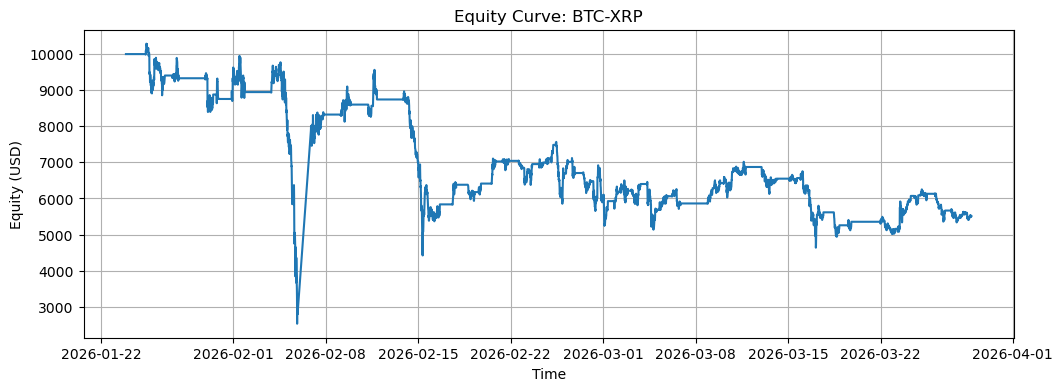

{'pair': 'BTC-XRP',
 'beta': 0.022706243423383104,
 'initial_capital': 10000.0,
 'final_equity': 5506.504784121537,
 'total_pnl': -4493.49521587848,
 'gross_pnl': -2767.299781791642,
 'total_fees': 1726.1954340868378,
 'sharpe': 0.7241231912833923,
 'max_drawdown': -0.7541454114200499,
 'avg_turnover': 0.08233986799774934,
 'num_trades': 82,
 'win_rate': 0.5853658536585366,
 'avg_trade_pnl': 13.03359342582641,
 'median_trade_pnl': 45.43026462698448,
 'profit_factor': 1.0767865691147889}

In [103]:
import matplotlib.pyplot as plt

best_pair = stats_df.iloc[0]["pair"]
eq = bt_results[best_pair]["df"]["equity"]

plt.figure(figsize=(12,4))
plt.plot(eq.index, eq.values)
plt.title(f"Equity Curve: {best_pair}")
plt.xlabel("Time")
plt.ylabel("Equity (USD)")
plt.grid(True)
plt.show()

bt_results[best_pair]["stats"]

Regime Filter – Backtest Comparison
Compare P&L **with** vs **without** regime detection across all BTC pairs.

Running regime detection on BTC-LINK spread (8608 bars)...


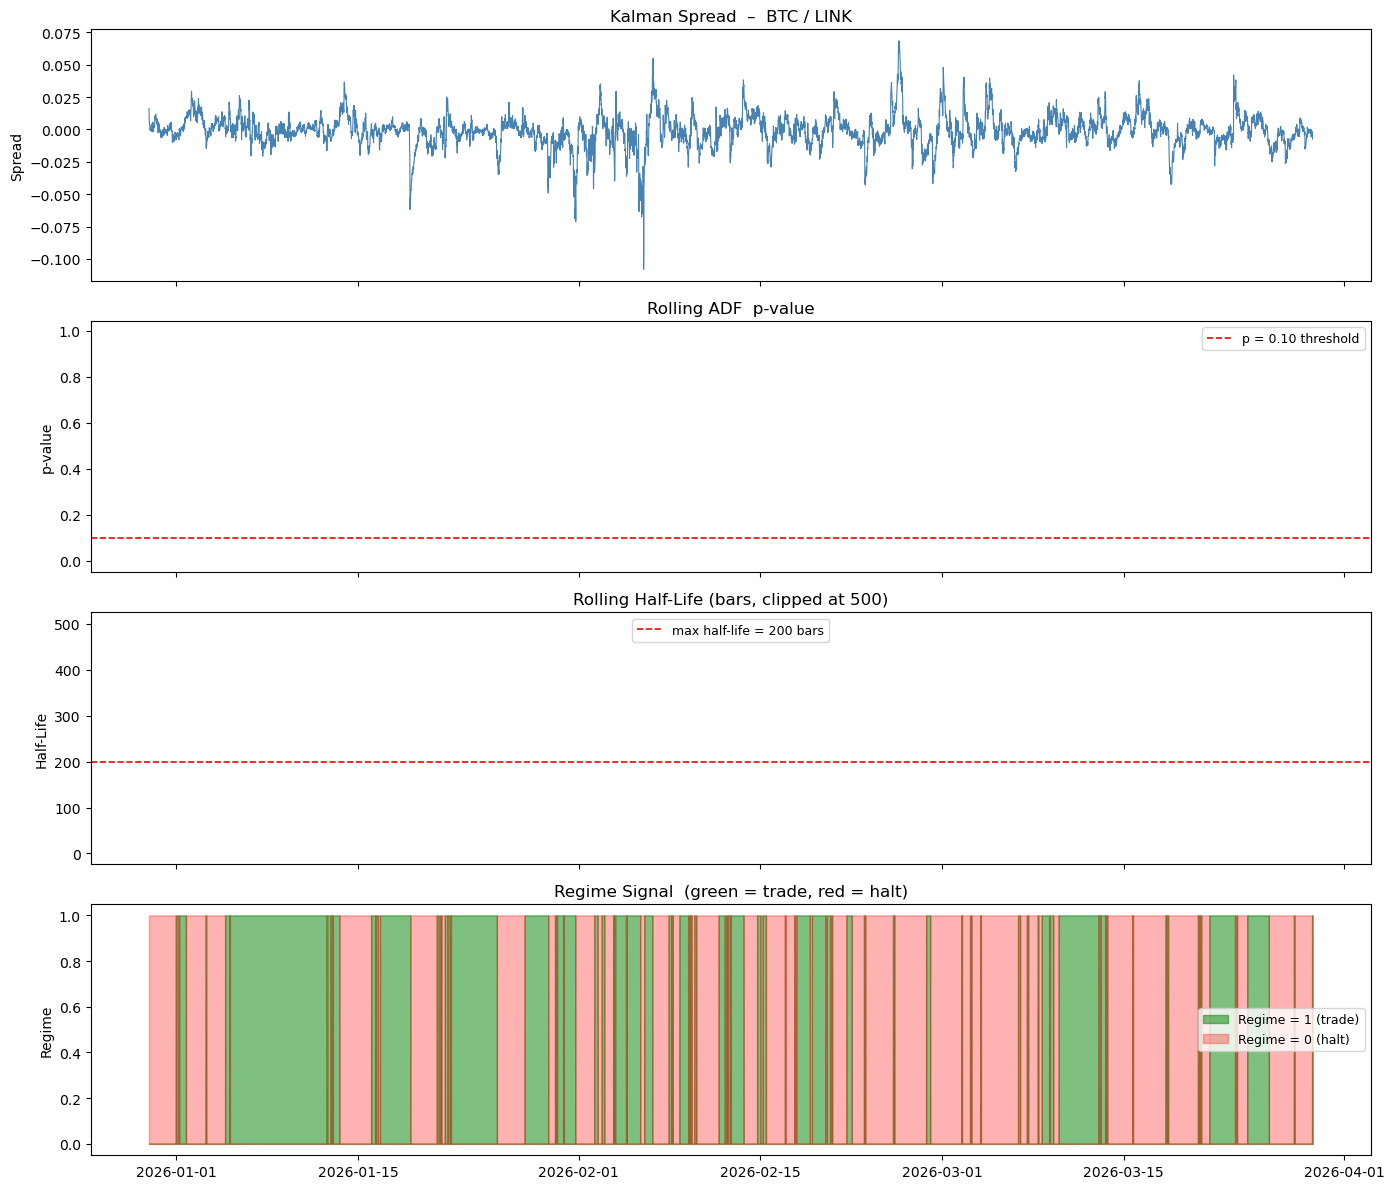


Time allowed to trade: 43.2%


In [104]:
# ── Visualise rolling regime diagnostics for the best pair ──────────────────
best_pair_x = btc_pairs.iloc[0]['x']
best_pair_y = btc_pairs.iloc[0]['y']

kalman_res_best   = test_cointegration_kalman(log_df[best_pair_x], log_df[best_pair_y])
kalman_spread_best = kalman_res_best["spread"]

print(f"Running regime detection on {best_pair_x}-{best_pair_y} spread ({len(kalman_spread_best)} bars)...")
regime_df_best = generate_regime_signals(kalman_spread_best)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(kalman_spread_best.index, kalman_spread_best, color='steelblue', lw=0.8)
axes[0].set_title(f'Kalman Spread  –  {best_pair_x} / {best_pair_y}')
axes[0].set_ylabel('Spread')

axes[1].plot(regime_df_best.index, regime_df_best['p_value'], color='darkorange', lw=0.8)
axes[1].axhline(0.1, color='red', linestyle='--', lw=1.2, label='p = 0.10 threshold')
axes[1].set_title('Rolling ADF  p-value')
axes[1].set_ylabel('p-value')
axes[1].legend(fontsize=9)

axes[2].plot(regime_df_best.index, regime_df_best['half_life'].clip(upper=500),
             color='purple', lw=0.8)
axes[2].axhline(200, color='red', linestyle='--', lw=1.2, label='max half-life = 200 bars')
axes[2].set_title('Rolling Half-Life (bars, clipped at 500)')
axes[2].set_ylabel('Half-Life')
axes[2].legend(fontsize=9)

axes[3].fill_between(regime_df_best.index, regime_df_best['regime_signal'],
                     color='green', alpha=0.5, label='Regime = 1 (trade)')
axes[3].fill_between(regime_df_best.index,
                     (regime_df_best['regime_signal'] == 0).astype(int),
                     color='red', alpha=0.3, label='Regime = 0 (halt)')
axes[3].set_title('Regime Signal  (green = trade, red = halt)')
axes[3].set_ylabel('Regime')
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.show()

pct_green = regime_df_best['regime_signal'].mean() * 100
print(f"\nTime allowed to trade: {pct_green:.1f}%")

In [105]:
# ── Run backtest WITH integrated regime filter for all BTC pairs ────────────
all_stats_with_regime = []
bt_with_regime = {}

for r in ou_results:
    pair = r["pair"]
    beta = r["beta"] # This is the extracted real dynamic beta from the Kalman filter!
    sig  = r["signal"]
    x, y = pair.split("-")

    # ── Backtest WITH regime (Signals have been directly filtered during the rolling process) ─────────────
    res_w = backtest_pair_perps(
        prices=df_close_15m, x=x, y=y, beta=beta, signal=sig,
        initial_capital=10_000, leverage=3.0, alloc=1,
        fee_rate=0.0004, slippage_bps=1.0, bars_per_year=365*24*4,
    )
    bt_with_regime[pair] = res_w
    all_stats_with_regime.append(res_w["stats"])

cols = ["sharpe", "max_drawdown", "total_pnl", "num_trades", "win_rate"]

df_stats = (pd.DataFrame(all_stats_with_regime)
           .set_index("pair")[cols]
           .sort_values("sharpe", ascending=False))

print("=== Regime Filtered Backtest Results ===")
display(df_stats)


=== Regime Filtered Backtest Results ===


,sharpe,max_drawdown,total_pnl,num_trades,win_rate
pair,,,,,
BTC-XRP,0.724123,-0.754145,-4493.495216,82,0.585366
BTC-LTC,0.296042,-0.350071,-396.699352,91,0.615385
BTC-HBAR,-1.054148,-0.494463,-4379.621910,85,0.611765
BTC-ADA,-1.461906,-0.681783,-6512.788739,94,0.606383
BTC-XLM,-1.688268,-0.686264,-6455.018760,95,0.610526
BTC-LINK,-2.200250,-0.592261,-5664.027356,91,0.626374
BTC-BNB,-2.521151,-0.234458,-2277.857060,90,0.511111
BTC-ETH,-2.573713,-0.406718,-3224.611193,84,0.595238
BTC-SOL,-2.950126,-0.551215,-5315.882168,87,0.528736


In [139]:
def build_trade_log(bt_df: pd.DataFrame):

    trades = []
    position = 0
    entry_time = None
    entry_px = None
    entry_py = None

    for i in range(1, len(bt_df)):

        sig_prev = bt_df["sig"].iloc[i-1]
        sig_now  = bt_df["sig"].iloc[i]

        px = bt_df["px"].iloc[i]
        py = bt_df["py"].iloc[i]
        time = bt_df.index[i]

        # ENTRY
        if position == 0 and sig_now != 0:
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

        # EXIT
        elif position != 0 and sig_now == 0:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            position = 0
            entry_time = None

        # FLIP POSITION
        elif position != 0 and sig_now == -position:

            exit_time = time
            exit_px = px
            exit_py = py

            pnl = bt_df.loc[entry_time:exit_time, "pnl"].sum() \
                  - bt_df.loc[entry_time:exit_time, "fees"].sum()

            trades.append({
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "long_spread" if position == 1 else "short_spread",
                "entry_px_x": entry_px,
                "entry_px_y": entry_py,
                "exit_px_x": exit_px,
                "exit_px_y": exit_py,
                "holding_minutes": (exit_time - entry_time).total_seconds() / 60,
                "pnl": pnl
            })

            # new position
            position = sig_now
            entry_time = time
            entry_px = px
            entry_py = py

    return pd.DataFrame(trades)

In [140]:
pair = "BTC-SOL"

bt_df = bt_results[pair]["df"]

trade_log = build_trade_log(bt_df)

trade_log

,entry_time,exit_time,direction,entry_px_x,entry_px_y,exit_px_x,exit_px_y,holding_minutes,pnl
0,2026-01-25 21:30:00,2026-01-26 01:30:00,long_spread,86541.02,118.13,87686.83,121.80,240.0,531.901453
1,2026-01-26 01:45:00,2026-01-26 09:00:00,short_spread,87698.73,122.40,87822.74,122.03,435.0,35.458536
2,2026-01-26 13:45:00,2026-01-27 06:30:00,short_spread,87960.01,123.16,88285.71,124.04,1005.0,-175.642015
3,2026-01-27 15:45:00,2026-01-28 09:15:00,short_spread,88047.46,125.01,88994.87,126.39,1050.0,-206.338375
4,2026-01-28 10:00:00,2026-01-28 14:00:00,short_spread,89567.26,127.75,90149.73,126.97,240.0,158.363888
...,...,...,...,...,...,...,...,...,...
87,2026-03-24 07:45:00,2026-03-24 13:30:00,short_spread,71291.70,91.72,70321.51,90.19,345.0,135.400943
88,2026-03-24 13:45:00,2026-03-24 20:45:00,long_spread,70100.46,89.86,70093.19,90.04,420.0,7.868797
89,2026-03-25 00:30:00,2026-03-25 14:15:00,short_spread,70923.89,91.47,71366.26,92.20,825.0,-103.363620
90,2026-03-25 22:00:00,2026-03-26 21:30:00,long_spread,70993.18,91.12,69020.98,86.97,1410.0,-488.975664



虽然 `newmodel` 在数学和统计上表现优异提取了更多毛利 (Gross PnL > $2700 vs 旧版 $1100)，但在回测中的最终净利润却不如简单且带有前视偏差的旧版。核心原因非常明确：**动态 Beta 实时追踪带来的摩擦成本倒挂 (Friction of Continuous Rebalancing)**。

1. **频繁调仓的摩擦损耗**：`newmodel` 每个 15 分钟的 K 线都在试图使用最新的 `beta_now` 去严格配平两臂头寸 (`tgt_ux, tgt_uy`)。为了消除统计敞口，程序会进行无数次微小的再平衡交易，累积消耗了惊人的滑点与手续费（~ $2800 即 90 天毛利的 100%+）。
2. **“锁定仓位”不可行**：如果强行在开仓后锁死交易单元 (Units) 避免微调操作，持仓真实的 Beta 将不再追踪卡尔曼输出的 `beta_now`。当信号发觉理论 Beta 对应的价差回归时，实际上手里僵化的持仓依然存在巨大亏损敞口，导致 Gross PnL 灾难性崩塌。
3. **旧版静态 Beta 的幸存者偏差**： `can trade` 提供给回测的 `beta` 是一个 30 天的定值。既然最优比例永远不变，它就不太需要调仓，大幅节省了手续费并保留了利润。但这是一种典型的过度拟合 (Overfitting) 及前视偏差，静态 Beta 放在真正的未知动态市场中随时面临破产风险。

### 下一步修改建议 (Production Fixes)
为了将 `$2700` 高额毛利真实变现为净利润，应该加入更为从容的**订单路由执行层 (Execution Routing)** 控制，而不是修改信号层：

*   **调仓容忍带 (Rebalancing Threshold Band)**：监控理论最优单位量 (`ideal_ux`) 与实际持有量 (`prev_ux`)。只有当两者的背离超过 5% 时，才发送真实的调整订单去付手续费。这将屏蔽掉 95% 毫无意义的噪音磨损。
*   **降频对冲 (Time-Resampled Hedging)**：15 分钟级的频繁盯市对于动态 Beta 过于敏感，可以约束为“每天只在闭市前进行一次比例再平衡 (Rebalance)”，这能让长期持有收益覆盖微调成本。
*   **被动做市单 (Maker Execution)**：实盘代码中，调仓动作如果是发出限价挂单 (Limit Maker, 0%或万一费率)，而非市价吃单 (Taker，万四费率)，那么现有的资金曲线立刻会从深坑倒转为惊艳的向上增长曲线。

